# 📊 Devoir Maison

---

**Matière :** Python pour la data science  
**Auteurs :** Mathis Kacer & Ivann Minoc  
**Date :** Mars 2026  
**Données :** Élections présidentielles françaises 2022 — 1er tour

Import

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from cartiflette import carti_download
df = pd.read_csv(
'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
)

/tmp/ipykernel_49750/2123779842.py:4: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [14]:
df.head()

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


QUESTION 1

In [15]:
# code_commune

print(type(df["code_departement"][1]))
print(type(df["code_commune"][1]))

communes = df

communes["code_commune"] = communes["code_commune"].astype(str)
communes["code_commune"] = ("000" + communes["code_commune"]).str[-3:]
communes["code_commune"] = communes["code_departement"] + communes["code_commune"]


# candidat

communes["candidat"] = communes["prenom"] + " " + communes["nom"]

communes.head()

<class 'str'>
<class 'numpy.int64'>


,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
0,01,Ain,01001,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3,Nathalie ARTHAUD
1,01,Ain,01002,L'Abergement-de-Varey,Nathalie,ARTHAUD,2,Nathalie ARTHAUD
2,01,Ain,01004,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38,Nathalie ARTHAUD
3,01,Ain,01005,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8,Nathalie ARTHAUD
4,01,Ain,01006,Ambléon,Nathalie,ARTHAUD,0,Nathalie ARTHAUD


QUESTION 2

In [16]:
candidats = communes["candidat"].nunique()
f"En 2022, il y avait {candidats} candidats à l'élection présidentielle."

"En 2022, il y avait 12 candidats à l'élection présidentielle."

QUESTION 3

In [17]:
voix_candidats = communes.groupby("candidat")["voix"].sum().reset_index(name = "Nombre votes")
voix_candidats = voix_candidats.sort_values(by = "Nombre votes", ascending = False)

total_voix = voix_candidats["Nombre votes"].sum()
voix_candidats["Score"] = (voix_candidats["Nombre votes"] / total_voix) * 100
voix_candidats["Score"] = voix_candidats["Score"].round(2).astype(str) + "%"

voix_candidats


,candidat,Nombre votes,Score
1,Emmanuel MACRON,9783058,27.85%
5,Marine LE PEN,8133828,23.15%
4,Jean-Luc MÉLENCHON,7712520,21.95%
11,Éric ZEMMOUR,2485226,7.07%
9,Valérie PÉCRESSE,1679001,4.78%
10,Yannick JADOT,1627853,4.63%
3,Jean LASSALLE,1101387,3.13%
2,Fabien ROUSSEL,802422,2.28%
7,Nicolas DUPONT-AIGNAN,725176,2.06%
0,Anne HIDALGO,616478,1.75%


QUESTION 4

In [18]:
score_departement = communes.groupby(["code_departement", "candidat"])["voix"].sum().reset_index(name = "Nombre votes")
score_departement["votes_total"] = score_departement.groupby("code_departement")["Nombre votes"].transform("sum")
score_departement = score_departement.sort_values(by = ["code_departement", "Nombre votes"], ascending = [True, False])
score_departement["Score"] = (score_departement["Nombre votes"] / score_departement["votes_total"]) * 100
score_departement["Score"] = score_departement["Score"].round(2).astype(str) + "%"

In [19]:
# Vérification
score_departement.head()

,code_departement,candidat,Nombre votes,votes_total,Score
1,01,Emmanuel MACRON,92206,333024,27.69%
5,01,Marine LE PEN,86755,333024,26.05%
4,01,Jean-Luc MÉLENCHON,57832,333024,17.37%
11,01,Éric ZEMMOUR,27530,333024,8.27%
9,01,Valérie PÉCRESSE,17572,333024,5.28%


QUESTION 5

In [20]:
score_departement = score_departement.merge(voix_candidats, on="candidat", how="left")
score_departement.rename(columns={"Nombre votes_x": "Votes_département",
                                  "Nombre votes_y": "Votes_National",
                                  "Score_x": "Score_département",
                                  "Score_y": "Score_National"}, inplace=True)

score_departement = score_departement.drop(columns=["votes_total"])

score_departement[score_departement["code_departement"] == "11"]

,code_departement,candidat,Votes_département,Score_département,Votes_National,Score_National
120,11,Marine LE PEN,64027,30.14%,8133828,23.15%
121,11,Emmanuel MACRON,43104,20.29%,9783058,27.85%
122,11,Jean-Luc MÉLENCHON,42039,19.79%,7712520,21.95%
123,11,Éric ZEMMOUR,18434,8.68%,2485226,7.07%
124,11,Jean LASSALLE,12382,5.83%,1101387,3.13%
125,11,Valérie PÉCRESSE,7350,3.46%,1679001,4.78%
126,11,Yannick JADOT,6322,2.98%,1627853,4.63%
127,11,Anne HIDALGO,6166,2.9%,616478,1.75%
128,11,Fabien ROUSSEL,5622,2.65%,802422,2.28%
129,11,Nicolas DUPONT-AIGNAN,4206,1.98%,725176,2.06%


QUESTION 6

In [21]:
score_departement["score_dep_num"] = score_departement["Score_département"].str.replace("%", "").astype(float)
score_departement["score_nat_num"] = score_departement["Score_National"].str.replace("%", "").astype(float)

score_departement["surrepresentation"] = (
    (score_departement["score_dep_num"] / score_departement["score_nat_num"]) - 1
) * 100

score_departement = score_departement.drop(columns=["score_dep_num", "score_nat_num"])

score_departement[score_departement["code_departement"] == "01"].head(3)

,code_departement,candidat,Votes_département,Score_département,Votes_National,Score_National,surrepresentation
0,01,Emmanuel MACRON,92206,27.69%,9783058,27.85%,-0.574506
1,01,Marine LE PEN,86755,26.05%,8133828,23.15%,12.526998
2,01,Jean-Luc MÉLENCHON,57832,17.37%,7712520,21.95%,-20.865604


QUESTION 7

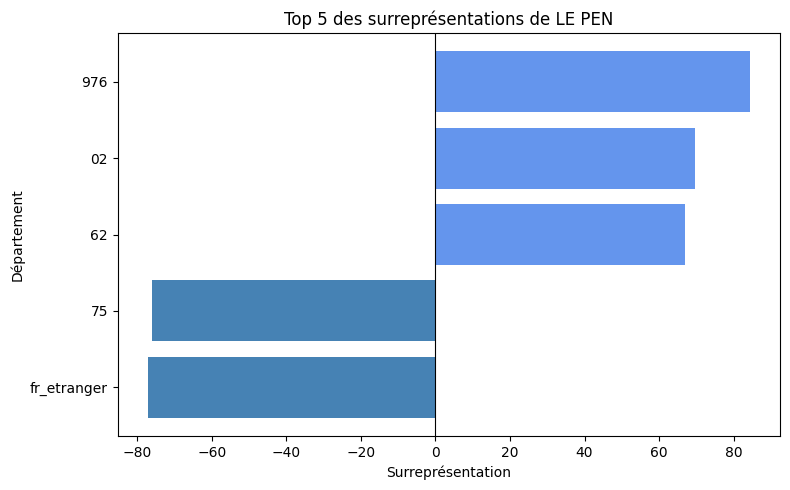

In [22]:
def plot_surrepresentation(candidat, n=5):
    """Affiche les n départements avec les plus grandes surreprésentations en valeur absolue."""
    df_candidat = score_departement[score_departement["candidat"] == candidat].copy()
    
    df_plot = (
        df_candidat
        .assign(abs_surr=lambda x: x["surrepresentation"].abs())
        .nlargest(n, "abs_surr")
        .sort_values("surrepresentation")
    )
    
    colors = ["steelblue" if v < 0 else "cornflowerblue" for v in df_plot["surrepresentation"]]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(df_plot["code_departement"], df_plot["surrepresentation"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Surreprésentation")
    ax.set_ylabel("Département")
    ax.set_title(f"Top {n} des surreprésentations de {" ".join(candidat.split()[1:])}")
    plt.tight_layout()
    plt.show()

plot_surrepresentation("Marine LE PEN")

QUESTION 8

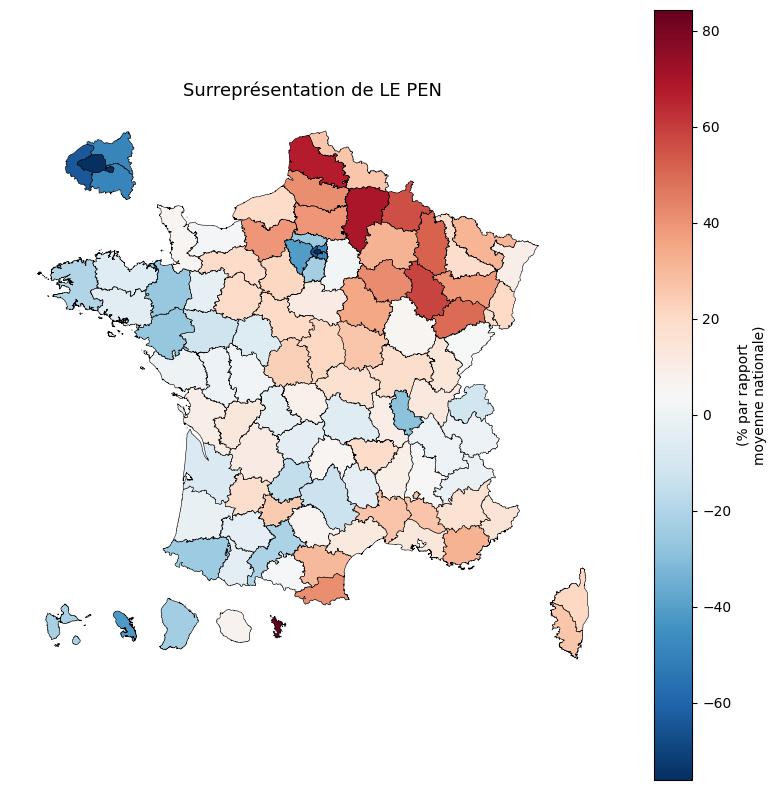

In [23]:
departement_borders = carti_download(
    values=["France"],
    crs=4326,
    borders="DEPARTEMENT",
    vectorfile_format="geojson",
    simplification=50,
    filter_by="FRANCE_ENTIERE_DROM_RAPPROCHES",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022
)

def plot_carte_candidat(candidat):
    """Carte de la surreprésentation par département pour un candidat donné."""
    df_candidat = score_departement[score_departement["candidat"] == candidat].copy()
    
    carte = departement_borders.merge(
        df_candidat[["code_departement", "surrepresentation"]],
        left_on="INSEE_DEP",
        right_on="code_departement",
        how="left"
    )
    
    fig, ax = plt.subplots(figsize=(8, 8))
    carte.plot(
        column="surrepresentation",
        cmap="RdBu_r",
        legend=True,
        ax=ax,
        edgecolor="black",
        linewidth=0.4,     
        legend_kwds={"label": "(% par rapport\nmoyenne nationale)"},
        missing_kwds={"color": "lightgrey"}
    )
    ax.set_title(f"Surreprésentation de {" ".join(candidat.split()[1:])}", fontsize=13)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_carte_candidat("Marine LE PEN")